In [ ]:
# F-03 Cell 1: Setup

import os
import sys
import subprocess
import glob
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import rasterio

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    jaccard_score,
    confusion_matrix
)

warnings.filterwarnings("ignore")

DATA_ROOT = "/content/sen1floods11"
SPLIT_DIR = os.path.join(DATA_ROOT, "splits")
DATA_DIR = os.path.join(DATA_ROOT, "data")
RESULTS_DIR = os.path.join(DATA_ROOT, "f03_results")

os.makedirs(SPLIT_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

print("F-03: VV + VH Flood Baseline")
print("Dataset directory:", DATA_ROOT)
print("Results directory:", RESULTS_DIR)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Setup complete.")

F-03: VV + VH Flood Baseline
Dataset directory: /content/sen1floods11
Results directory: /content/sen1floods11/f03_results
NumPy: 2.1.3
Pandas: 2.2.3
Setup complete.


In [ ]:
# F-03 Cell 2: Check Sen1Floods11 source

bucket = "gs://sen1floods11/v1.1"

result = subprocess.run(
    ["gsutil", "ls", bucket + "/splits/flood_handlabeled/"],
    capture_output=True,
    text=True
)

if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError(
        "Could not access the dataset bucket. Check the error above."
    )

print(result.stdout)
print("Dataset source is accessible.")

gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_bolivia_data.csv
gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_test_data.csv
gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_train_data.csv
gs://sen1floods11/v1.1/splits/flood_handlabeled/flood_valid_data.csv

Dataset source is accessible.


In [ ]:
# F-03 Cell 3: Download split CSV files

bucket = "gs://sen1floods11/v1.1"

split_files = [
    "flood_train_data.csv",
    "flood_valid_data.csv",
    "flood_test_data.csv"
]

for filename in split_files:
    destination = os.path.join(SPLIT_DIR, filename)

    if not os.path.exists(destination):
        subprocess.run(
            [
                "gsutil", "cp",
                f"{bucket}/splits/flood_handlabeled/{filename}",
                destination
            ],
            check=True
        )

    print("Ready:", filename)

print("Split-file setup complete.")

Ready: flood_train_data.csv
Ready: flood_valid_data.csv
Ready: flood_test_data.csv
Split-file setup complete.


In [ ]:
# F-03 Cell 4: Inspect CSV structure without assuming a header

split_paths = {
    "train": os.path.join(SPLIT_DIR, "flood_train_data.csv"),
    "valid": os.path.join(SPLIT_DIR, "flood_valid_data.csv"),
    "test": os.path.join(SPLIT_DIR, "flood_test_data.csv")
}

for split_name, path in split_paths.items():
    print(f"\n{split_name.upper()} CSV")
    print("File size:", os.path.getsize(path), "bytes")

    with open(path, "r", encoding="utf-8-sig") as file:
        for _ in range(3):
            line = file.readline()
            if not line:
                break
            print(repr(line.rstrip("\n")))


TRAIN CSV
File size: 13574 bytes
'Ghana_103272_S1Hand.tif,Ghana_103272_LabelHand.tif'
'Ghana_24858_S1Hand.tif,Ghana_24858_LabelHand.tif'
'Ghana_147015_S1Hand.tif,Ghana_147015_LabelHand.tif'

VALID CSV
File size: 4804 bytes
'Ghana_5079_S1Hand.tif,Ghana_5079_LabelHand.tif'
'Ghana_895194_S1Hand.tif,Ghana_895194_LabelHand.tif'
'Ghana_868803_S1Hand.tif,Ghana_868803_LabelHand.tif'

TEST CSV
File size: 4858 bytes
'Ghana_313799_S1Hand.tif,Ghana_313799_LabelHand.tif'
'Ghana_1078550_S1Hand.tif,Ghana_1078550_LabelHand.tif'
'Ghana_97059_S1Hand.tif,Ghana_97059_LabelHand.tif'


In [ ]:
# F-03 Cell 5: Parse the split CSVs

import csv

def parse_pairs(csv_path):
    pairs = []

    with open(csv_path, "r", encoding="utf-8-sig", newline="") as file:
        reader = csv.reader(file)

        for row in reader:
            names = [
                item.strip().strip('"').strip("'")
                for item in row
                if item.strip()
            ]

            s1_files = [x for x in names if x.endswith("_S1Hand.tif")]
            label_files = [x for x in names if x.endswith("_LabelHand.tif")]

            if len(s1_files) == 1 and len(label_files) == 1:
                pairs.append({
                    "s1": s1_files[0],
                    "label": label_files[0]
                })

    # Remove duplicate pairs, preserving order.
    unique = []
    seen = set()

    for pair in pairs:
        key = (pair["s1"], pair["label"])
        if key not in seen:
            seen.add(key)
            unique.append(pair)

    return unique


pairs = {
    name: parse_pairs(path)
    for name, path in split_paths.items()
}

for name, items in pairs.items():
    print(f"{name}: {len(items)} paired samples")
    print("Example:", items[0] if items else "No pairs found")

if any(len(items) == 0 for items in pairs.values()):
    raise ValueError(
        "At least one split produced zero image-label pairs. "
        "Inspect Cell 4 output before continuing."
    )

train: 252 paired samples
Example: {'s1': 'Ghana_103272_S1Hand.tif', 'label': 'Ghana_103272_LabelHand.tif'}
valid: 89 paired samples
Example: {'s1': 'Ghana_5079_S1Hand.tif', 'label': 'Ghana_5079_LabelHand.tif'}
test: 90 paired samples
Example: {'s1': 'Ghana_313799_S1Hand.tif', 'label': 'Ghana_313799_LabelHand.tif'}


In [ ]:
# F-03 Cell 6: Build a remote raster file index

bucket = "gs://sen1floods11/v1.1/data/flood_events"

listing = subprocess.run(
    ["gsutil", "ls", "-r", bucket + "/**"],
    capture_output=True,
    text=True
)

if listing.returncode != 0:
    print(listing.stderr)
    raise RuntimeError("Could not list the raster files.")

remote_paths = [
    line.strip()
    for line in listing.stdout.splitlines()
    if line.strip().endswith(".tif")
]

remote_index = {}

for path in remote_paths:
    basename = path.rsplit("/", 1)[-1]
    remote_index.setdefault(basename, []).append(path)

print("Remote TIFF files indexed:", len(remote_paths))
print("Distinct filenames:", len(remote_index))

needed_names = set()

for items in pairs.values():
    for pair in items:
        needed_names.add(pair["s1"])
        needed_names.add(pair["label"])

missing_names = sorted(
    name for name in needed_names
    if name not in remote_index
)

print("Required filenames:", len(needed_names))
print("Missing filenames:", len(missing_names))

if missing_names:
    print("Examples of missing filenames:", missing_names[:10])
    raise FileNotFoundError(
        "Some required raster files were not found in the flood_events "
        "directory. Do not continue until the paths are checked."
    )

print("All required filenames were found.")

Remote TIFF files indexed: 19766
Distinct filenames: 19766
Required filenames: 862
Missing filenames: 0
All required filenames were found.


In [ ]:
# F-03 Cell 7: Download the required raster pairs

local_index = {}

for name in sorted(needed_names):
    remote_matches = remote_index[name]

    if len(remote_matches) != 1:
        raise ValueError(
            f"Expected one remote path for {name}, "
            f"but found {len(remote_matches)}. "
            "Resolve the path ambiguity before downloading."
        )

    local_path = os.path.join(DATA_DIR, name)

    if not os.path.exists(local_path):
        subprocess.run(
            ["gsutil", "cp", remote_matches[0], local_path],
            check=True
        )

    local_index[name] = local_path

print("Required raster files are ready.")
print("Local files:", len(local_index))

Required raster files are ready.
Local files: 862


In [ ]:

# F-03 Cell 8 — Load paired Sentinel-1 image and label safely

import os
import numpy as np
import rasterio

def load_pair(pair):
    s1_path = local_index[pair["s1"]]
    label_path = local_index[pair["label"]]

    with rasterio.open(s1_path) as src:
        s1 = src.read()
        s1_crs = src.crs
        s1_transform = src.transform
        s1_shape = (src.height, src.width)
        s1_bounds = src.bounds

    with rasterio.open(label_path) as src:
        label = src.read(1)
        label_crs = src.crs
        label_transform = src.transform
        label_shape = (src.height, src.width)
        label_bounds = src.bounds

    # Sentinel-1 bands: band 1 = VV, band 2 = VH
    vv = s1[0].astype(np.float32)
    vh = s1[1].astype(np.float32)

    # Do not silently resize or reproject either raster.
    if vv.shape != label.shape:
        raise ValueError(
            f"Pixel dimensions differ: image={vv.shape}, label={label.shape}. "
            "These files need further investigation before evaluation."
        )

    # Report metadata differences for the experiment record.
    if s1_crs != label_crs:
        print("WARNING: CRS mismatch:", s1_crs, "vs", label_crs)

    if s1_transform != label_transform:
        print("WARNING: Affine transform mismatch.")
        print("Image transform:", s1_transform)
        print("Label transform:", label_transform)

    if s1_bounds != label_bounds:
        print("WARNING: Bounds mismatch.")
        print("Image bounds:", s1_bounds)
        print("Label bounds:", label_bounds)

    return vv, vh, label


# Test with the first training pair
sample = pairs["train"][0]
vv, vh, label = load_pair(sample)

print("\nSample:", sample)
print("VV shape:", vv.shape)
print("VH shape:", vh.shape)
print("Label shape:", label.shape)
print("VV finite pixels:", np.isfinite(vv).sum())
print("VH finite pixels:", np.isfinite(vh).sum())
print("Label values:", np.unique(label, return_counts=True))

Image transform: | 0.00, 0.00,-1.15|
| 0.00,-0.00, 9.47|
| 0.00, 0.00, 1.00|
Label transform: | 0.00, 0.00,-1.15|
| 0.00,-0.00, 9.47|
| 0.00, 0.00, 1.00|
Image bounds: BoundingBox(left=-1.1498435636729876, bottom=9.428717222118498, right=-1.103849821126068, top=9.474710964665418)
Label bounds: BoundingBox(left=-1.1498435636729876, bottom=9.428717222118498, right=-1.1038498211260683, top=9.474710964665418)

Sample: {'s1': 'Ghana_103272_S1Hand.tif', 'label': 'Ghana_103272_LabelHand.tif'}
VV shape: (512, 512)
VH shape: (512, 512)
Label shape: (512, 512)
VV finite pixels: 262144
VH finite pixels: 262144
Label values: (array([-1,  0,  1], dtype=int16), array([  2875, 257711,   1558]))


In [ ]:
# F-03 Cell 9: Confirm label semantics

label_values, label_counts = np.unique(label, return_counts=True)

print("Observed label distribution:")
for value, count in zip(label_values, label_counts):
    print(f"Value {value}: {count} pixels")

print("\nThe F-02 workflow treated label value 1 as flooded.")
print("We will preserve that convention for F-03.")

if 1 not in label_values:
    print(
        "WARNING: This particular sample has no pixels labelled 1. "
        "Check another sample before interpreting results."
    )

Observed label distribution:
Value -1: 2875 pixels
Value 0: 257711 pixels
Value 1: 1558 pixels

The F-02 workflow treated label value 1 as flooded.
We will preserve that convention for F-03.


In [ ]:
# F-03 Cell 10: Binary evaluation metrics

def calculate_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    y_true = (y_true == 1).astype(np.uint8).ravel()
    y_pred = (y_pred == 1).astype(np.uint8).ravel()

    precision = precision_score(
        y_true, y_pred, zero_division=0
    )
    recall = recall_score(
        y_true, y_pred, zero_division=0
    )
    f1 = f1_score(
        y_true, y_pred, zero_division=0
    )
    iou = jaccard_score(
        y_true, y_pred, zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred, labels=[0, 1]
    ).ravel()

    false_alarm_rate = (
        fp / (fp + tn) if (fp + tn) else 0.0
    )
    missed_flood_rate = (
        fn / (fn + tp) if (fn + tp) else 0.0
    )

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "iou": iou,
        "false_alarm_rate": false_alarm_rate,
        "missed_flood_rate": missed_flood_rate,
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp)
    }

print("Metric function ready.")

Metric function ready.


In [ ]:
# F-03 Cell 11: VV-only threshold predictor

def predict_vv(vv, threshold):
    prediction = np.zeros(vv.shape, dtype=np.uint8)
    valid = np.isfinite(vv)
    prediction[valid & (vv < threshold)] = 1
    return prediction

print("VV-only predictor ready.")

VV-only predictor ready.


In [ ]:
# F-03 Cell 12: VV + VH predictor

def predict_vv_vh(vv, vh, vv_threshold, vh_threshold):
    prediction = np.zeros(vv.shape, dtype=np.uint8)

    valid = np.isfinite(vv) & np.isfinite(vh)

    flood_candidate = (
        (vv < vv_threshold) &
        (vh < vh_threshold)
    )

    prediction[valid & flood_candidate] = 1

    return prediction

print("VV + VH predictor ready.")

VV + VH predictor ready.


In [ ]:
# F-03 Cell 13: Load validation data

validation_data = []

for i, pair in enumerate(pairs["valid"], start=1):
    vv, vh, label = load_pair(pair)

    valid = (
        np.isfinite(vv) &
        np.isfinite(vh)
    )

    validation_data.append({
        "name": pair["s1"],
        "vv": vv,
        "vh": vh,
        "label": label,
        "valid": valid
    })

    if i % 20 == 0 or i == len(pairs["valid"]):
        print(f"Loaded {i}/{len(pairs['valid'])} validation samples")

print("Validation data loaded:", len(validation_data))

Image transform: | 0.00, 0.00,-1.66|
| 0.00,-0.00, 9.11|
| 0.00, 0.00, 1.00|
Label transform: | 0.00, 0.00,-1.66|
| 0.00,-0.00, 9.11|
| 0.00, 0.00, 1.00|
Image bounds: BoundingBox(left=-1.655774731689102, bottom=9.060767281743141, right=-1.6097809891421826, top=9.10676102429006)
Label bounds: BoundingBox(left=-1.655774731689102, bottom=9.060767281743141, right=-1.6097809891421828, top=9.10676102429006)
Image transform: | 0.00, 0.00,-1.20|
| 0.00,-0.00, 9.20|
| 0.00, 0.00, 1.00|
Label transform: | 0.00, 0.00,-1.20|
| 0.00,-0.00, 9.20|
| 0.00, 0.00, 1.00|
Image bounds: BoundingBox(left=-1.195837306219907, bottom=9.152754766836981, right=-1.1498435636729876, top=9.1987485093839)
Label bounds: BoundingBox(left=-1.195837306219907, bottom=9.152754766836981, right=-1.1498435636729878, top=9.1987485093839)
Image transform: | 0.00, 0.00,-1.01|
| 0.00,-0.00, 10.03|
| 0.00, 0.00, 1.00|
Label transform: | 0.00, 0.00,-1.01|
| 0.00,-0.00, 10.03|
| 0.00, 0.00, 1.00|
Image bounds: BoundingBox(left=-1.

In [ ]:
# F-03 Cell 14: Validation threshold search for VV-only

thresholds = np.arange(-20.0, 1.0, 1.0)
vv_validation_results = []

for threshold in thresholds:
    all_true = []
    all_pred = []

    for item in validation_data:
        vv = item["vv"]
        label = item["label"]
        valid = np.isfinite(vv)

        pred = predict_vv(vv, threshold)

        all_true.append(label[valid].ravel())
        all_pred.append(pred[valid].ravel())

    metrics = calculate_metrics(
        np.concatenate(all_true),
        np.concatenate(all_pred)
    )

    vv_validation_results.append({
        "vv_threshold": threshold,
        **metrics
    })

vv_validation_df = pd.DataFrame(vv_validation_results)
vv_validation_df.to_csv(
    os.path.join(RESULTS_DIR, "F03_vv_validation.csv"),
    index=False
)

best_vv_row = vv_validation_df.loc[
    vv_validation_df["f1"].idxmax()
]

BEST_VV_THRESHOLD = float(best_vv_row["vv_threshold"])

print("Best VV threshold:", BEST_VV_THRESHOLD)
print("Validation F1:", round(float(best_vv_row["f1"]), 4))
display(vv_validation_df.sort_values("f1", ascending=False).head(10))

Best VV threshold: -17.0
Validation F1: 0.5939


,vv_threshold,precision,recall,f1,iou,false_alarm_rate,missed_flood_rate,TN,FP,FN,TP
3,-17.0,0.673893,0.530872,0.593893,0.422367,0.027452,0.469128,20306851,573190,1046721,1184485
2,-18.0,0.737859,0.486451,0.586342,0.414769,0.018468,0.513549,20494438,385603,1145834,1085372
4,-16.0,0.598351,0.574000,0.585922,0.414350,0.041173,0.426000,20020350,859691,950494,1280712
1,-19.0,0.789492,0.438652,0.563961,0.392719,0.012498,0.561348,20619076,260965,1252482,978724
5,-15.0,0.514744,0.618042,0.561683,0.390514,0.062260,0.381958,19580059,1299982,852227,1378979
0,-20.0,0.829054,0.385192,0.525997,0.356850,0.008487,0.614808,20702829,177212,1371763,859443
6,-14.0,0.428418,0.663767,0.520735,0.352023,0.094631,0.336233,18904132,1975909,750205,1481001
7,-13.0,0.346565,0.711405,0.466078,0.303847,0.143332,0.288595,17887267,2992774,643914,1587292
8,-12.0,0.274666,0.760403,0.403562,0.252789,0.214578,0.239597,16399654,4480387,534591,1696615
9,-11.0,0.216535,0.808550,0.341589,0.205974,0.312614,0.191450,14352654,6527387,427164,1804042


In [ ]:

# F-03 Cell 15 — FAST, FAIR VV + VH threshold tuning

import numpy as np
import pandas as pd
import os
import time

start_time = time.time()
rng = np.random.default_rng(42)

# Use the same VV and VH thresholds for both methods' comparison.
vv_thresholds = np.arange(-20.0, 1.0, 2.0)
vh_thresholds = np.arange(-27.0, -4.0, 2.0)

# Sample up to 10,000 valid pixels from each validation image.
# This makes threshold selection much faster than scanning every
# pixel for every threshold combination.
sampled_vv = []
sampled_vh = []
sampled_y = []

print("Sampling validation pixels...", flush=True)

for i, item in enumerate(validation_data):
    vv = np.asarray(item["vv"])
    vh = np.asarray(item["vh"])
    label = np.asarray(item["label"])

    valid = np.isfinite(vv) & np.isfinite(vh) & np.isfinite(label)

    vv_flat = vv[valid].ravel()
    vh_flat = vh[valid].ravel()
    y_flat = (label[valid].ravel() == 1).astype(np.uint8)

    if len(y_flat) == 0:
        continue

    # Randomly select a maximum of 10,000 pixels per image.
    n = min(10000, len(y_flat))
    indices = rng.choice(len(y_flat), size=n, replace=False)

    sampled_vv.append(vv_flat[indices])
    sampled_vh.append(vh_flat[indices])
    sampled_y.append(y_flat[indices])

    if (i + 1) % 20 == 0 or (i + 1) == len(validation_data):
        print(f"Processed {i + 1}/{len(validation_data)} validation images",
              flush=True)

# Combine the sampled pixels
sample_vv = np.concatenate(sampled_vv)
sample_vh = np.concatenate(sampled_vh)
sample_y = np.concatenate(sampled_y)

print("Sampled pixels:", len(sample_y))
print("Flood pixels:", int(sample_y.sum()))
print("Non-flood pixels:", int((sample_y == 0).sum()))

if sample_y.sum() == 0:
    raise ValueError("No flood pixels in the validation sample. Check label encoding.")

# Calculate F1 directly and safely
def fast_f1(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    denominator = 2 * tp + fp + fn
    return (2 * tp / denominator) if denominator else 0.0

# Tune VV-only baseline
vv_results = []

for threshold in vv_thresholds:
    pred = (sample_vv < threshold).astype(np.uint8)
    vv_results.append({
        "vv_threshold": float(threshold),
        "f1": fast_f1(sample_y, pred)
    })

vv_results_df = pd.DataFrame(vv_results)
vv_results_df.to_csv(
    os.path.join(RESULTS_DIR, "F03_vv_validation.csv"),
    index=False
)

best_vv_row = vv_results_df.loc[vv_results_df["f1"].idxmax()]
BEST_VV_THRESHOLD = float(best_vv_row["vv_threshold"])

print("\nBest VV-only threshold:", BEST_VV_THRESHOLD)
print("Sampled validation F1:", round(float(best_vv_row["f1"]), 4))

# Tune VV + VH baseline
# Flood prediction: VV < threshold AND VH < threshold
fusion_results = []

total = len(vv_thresholds) * len(vh_thresholds)
count = 0

for vv_t in vv_thresholds:
    for vh_t in vh_thresholds:
        pred = (
            (sample_vv < vv_t) &
            (sample_vh < vh_t)
        ).astype(np.uint8)

        fusion_results.append({
            "vv_threshold": float(vv_t),
            "vh_threshold": float(vh_t),
            "f1": fast_f1(sample_y, pred)
        })

        count += 1

        if count % 20 == 0 or count == total:
            print(f"Threshold combinations: {count}/{total}", flush=True)

fusion_df = pd.DataFrame(fusion_results)
fusion_df.to_csv(
    os.path.join(RESULTS_DIR, "F03_vv_vh_validation.csv"),
    index=False
)

best_row = fusion_df.loc[fusion_df["f1"].idxmax()]
BEST_VV_THRESHOLD = float(best_row["vv_threshold"])
BEST_VH_THRESHOLD = float(best_row["vh_threshold"])

print("\n--- Selected thresholds ---")
print("VV-only best threshold:", float(vv_results_df.loc[
    vv_results_df["f1"].idxmax(), "vv_threshold"
]))
print("VV + VH best VV threshold:", BEST_VV_THRESHOLD)
print("VV + VH best VH threshold:", BEST_VH_THRESHOLD)
print("VV + VH sampled validation F1:", round(float(best_row["f1"]), 4))
print("Elapsed seconds:", round(time.time() - start_time, 1))
print("Cell 15 completed.")

Sampling validation pixels...
Processed 20/89 validation images
Processed 40/89 validation images
Processed 60/89 validation images
Processed 80/89 validation images
Processed 89/89 validation images
Sampled pixels: 890000
Flood pixels: 86365
Non-flood pixels: 803635

Best VV-only threshold: -16.0
Sampled validation F1: 0.5871
Threshold combinations: 20/132
Threshold combinations: 40/132
Threshold combinations: 60/132
Threshold combinations: 80/132
Threshold combinations: 100/132
Threshold combinations: 120/132
Threshold combinations: 132/132

--- Selected thresholds ---
VV-only best threshold: -16.0
VV + VH best VV threshold: 0.0
VV + VH best VH threshold: -23.0
VV + VH sampled validation F1: 0.6111
Elapsed seconds: 1.1
Cell 15 completed.


In [47]:
# F-03 Cell 16: Load test samples

test_data = []

for i, pair in enumerate(pairs["test"], start=1):
    vv, vh, label = load_pair(pair)

    valid = (
        np.isfinite(vv) &
        np.isfinite(vh)
    )

    test_data.append({
        "name": pair["s1"],
        "vv": vv,
        "vh": vh,
        "label": label,
        "valid": valid
    })

    if i % 20 == 0 or i == len(pairs["test"]):
        print(f"Loaded {i}/{len(pairs['test'])} test samples")

print("Test samples loaded:", len(test_data))

Image transform: | 0.00, 0.00,-1.47|
| 0.00,-0.00, 9.34|
| 0.00, 0.00, 1.00|
Label transform: | 0.00, 0.00,-1.47|
| 0.00,-0.00, 9.34|
| 0.00, 0.00, 1.00|
Image bounds: BoundingBox(left=-1.471799761501424, bottom=9.290735994477739, right=-1.4258060189545045, top=9.336729737024658)
Label bounds: BoundingBox(left=-1.471799761501424, bottom=9.290735994477739, right=-1.4258060189545048, top=9.336729737024658)
Image transform: | 0.00, 0.00,-1.15|
| 0.00,-0.00, 10.67|
| 0.00, 0.00, 1.00|
Label transform: | 0.00, 0.00,-1.15|
| 0.00,-0.00, 10.67|
| 0.00, 0.00, 1.00|
Image bounds: BoundingBox(left=-1.1498435636729876, bottom=10.624554528338404, right=-1.103849821126068, top=10.670548270885323)
Label bounds: BoundingBox(left=-1.1498435636729876, bottom=10.624554528338404, right=-1.1038498211260683, top=10.670548270885323)
Image transform: | 0.00, 0.00,-1.01|
| 0.00,-0.00, 9.01|
| 0.00, 0.00, 1.00|
Label transform: | 0.00, 0.00,-1.01|
| 0.00,-0.00, 9.01|
| 0.00, 0.00, 1.00|
Image bounds: BoundingB

In [49]:

# F-03 Cell 17 — Test evaluation: VV-only vs VV + VH

import numpy as np
import pandas as pd
import os
import time

test_rows = []
per_sample_rows = []

all_y = []
all_vv_pred = []
all_fusion_pred = []

start_time = time.time()

# Correct variable names defined by Cell 15
vv_only_threshold = float(
    vv_results_df.loc[vv_results_df["f1"].idxmax(), "vv_threshold"]
)
fusion_vv_threshold = BEST_VV_THRESHOLD
fusion_vh_threshold = BEST_VH_THRESHOLD

print("VV-only threshold:", vv_only_threshold)
print("VV + VH thresholds:", fusion_vv_threshold, fusion_vh_threshold)
print("Evaluating test samples...", flush=True)

for i, item in enumerate(test_data):
    vv = np.asarray(item["vv"])
    vh = np.asarray(item["vh"])
    label = np.asarray(item["label"])

    # Common valid pixels ensure a fair comparison
    valid = np.isfinite(vv) & np.isfinite(vh) & np.isfinite(label)

    if not np.any(valid):
        print(f"Skipping sample {i + 1}: no valid pixels")
        continue

    y_true = (label[valid] == 1).astype(np.uint8)

    pred_vv = (vv[valid] < vv_only_threshold).astype(np.uint8)

    pred_vv_vh = (
        (vv[valid] < fusion_vv_threshold) &
        (vh[valid] < fusion_vh_threshold)
    ).astype(np.uint8)

    # Collect common pixels for pooled test metrics
    all_y.append(y_true)
    all_vv_pred.append(pred_vv)
    all_fusion_pred.append(pred_vv_vh)

    # Per-sample metrics
    metrics_vv = calculate_metrics(y_true, pred_vv)
    metrics_fusion = calculate_metrics(y_true, pred_vv_vh)

    sample_name = item.get("name", f"test_sample_{i + 1}")

    per_sample_rows.append({
        "sample": sample_name,
        "valid_pixels": len(y_true),
        "VV_precision": metrics_vv["precision"],
        "VV_recall": metrics_vv["recall"],
        "VV_F1": metrics_vv["f1"],
        "VV_IoU": metrics_vv["iou"],
        "VV_VH_precision": metrics_fusion["precision"],
        "VV_VH_recall": metrics_fusion["recall"],
        "VV_VH_F1": metrics_fusion["f1"],
        "VV_VH_IoU": metrics_fusion["iou"]
    })

    if (i + 1) % 10 == 0 or (i + 1) == len(test_data):
        print(f"Processed {i + 1}/{len(test_data)} test samples",
              flush=True)

if not all_y:
    raise ValueError("No valid test pixels were evaluated.")

y_test = np.concatenate(all_y)
pred_test_vv = np.concatenate(all_vv_pred)
pred_test_fusion = np.concatenate(all_fusion_pred)

metrics_vv = calculate_metrics(y_test, pred_test_vv)
metrics_fusion = calculate_metrics(y_test, pred_test_fusion)

test_comparison = pd.DataFrame([
    {"method": "VV-only", **metrics_vv},
    {"method": "VV + VH", **metrics_fusion}
])

test_comparison.to_csv(
    os.path.join(RESULTS_DIR, "F03_test_comparison.csv"),
    index=False
)

per_sample_df = pd.DataFrame(per_sample_rows)
per_sample_df.to_csv(
    os.path.join(RESULTS_DIR, "F03_per_sample_results.csv"),
    index=False
)

print("\n--- Pooled test metrics ---")
display(test_comparison)

print("Per-sample results saved.")
print("Elapsed seconds:", round(time.time() - start_time, 1))
print("Cell 17 completed.")

VV-only threshold: -16.0
VV + VH thresholds: -17.0 -23.0
Evaluating test samples...
Processed 10/90 test samples
Processed 20/90 test samples
Processed 30/90 test samples
Processed 40/90 test samples
Processed 50/90 test samples
Skipping sample 51: no valid pixels
Processed 60/90 test samples
Processed 70/90 test samples
Processed 80/90 test samples
Processed 90/90 test samples

--- Pooled test metrics ---


,method,precision,recall,f1,iou,false_alarm_rate,missed_flood_rate,TN,FP,FN,TP
0,VV-only,0.624433,0.569077,0.595472,0.423965,0.041956,0.430923,19656337,860819,1083774,1431234
1,VV + VH,0.756744,0.487437,0.592945,0.421408,0.019207,0.512563,20123087,394069,1289099,1225909


Per-sample results saved.
Elapsed seconds: 61.6
Cell 17 completed.


In [50]:

# F-03 Cell 18 — Difference between the two methods

vv_row = test_comparison[test_comparison["method"] == "VV-only"].iloc[0]
fusion_row = test_comparison[test_comparison["method"] == "VV + VH"].iloc[0]

comparison_metrics = ["precision", "recall", "f1", "iou"]

differences = []

for metric in comparison_metrics:
    differences.append({
        "metric": metric,
        "VV_only": float(vv_row[metric]),
        "VV_plus_VH": float(fusion_row[metric]),
        "difference": float(fusion_row[metric] - vv_row[metric])
    })

differences_df = pd.DataFrame(differences)

differences_path = os.path.join(
    RESULTS_DIR, "F03_metric_differences.csv"
)
differences_df.to_csv(differences_path, index=False)

display(differences_df)
print("Saved:", differences_path)

,metric,VV_only,VV_plus_VH,difference
0,precision,0.624433,0.756744,0.132311
1,recall,0.569077,0.487437,-0.081640
2,f1,0.595472,0.592945,-0.002527
3,iou,0.423965,0.421408,-0.002557


Saved: /content/sen1floods11/f03_results/F03_metric_differences.csv


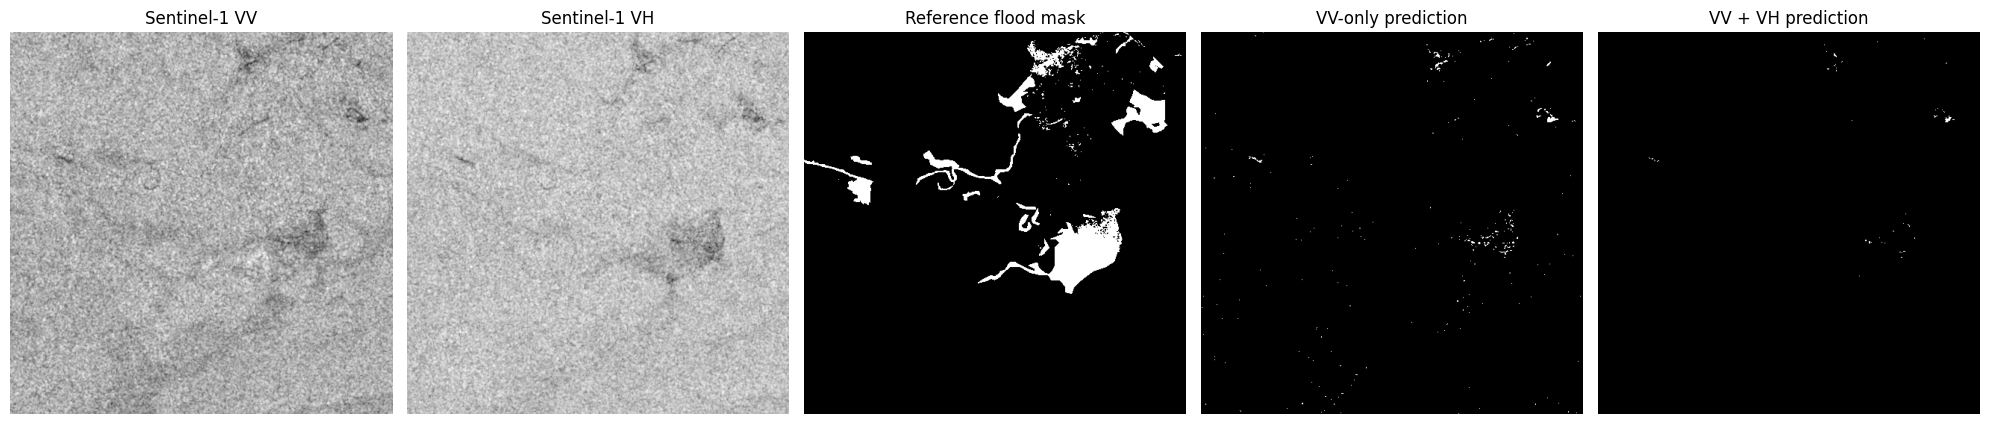

Saved: /content/sen1floods11/f03_results/F03_vv_vh_visual_comparison.png


In [51]:

# F-03 Cell 19 — Visual comparison of one test sample

import matplotlib.pyplot as plt
import rasterio
import os
import numpy as np

sample = test_data[0]
vv = np.asarray(sample["vv"])
vh = np.asarray(sample["vh"])
label = np.asarray(sample["label"])

prediction_vv = (vv < vv_only_threshold).astype(np.uint8)
prediction_fusion = (
    (vv < fusion_vv_threshold) &
    (vh < fusion_vh_threshold)
).astype(np.uint8)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

axes[0].imshow(vv, cmap="gray")
axes[0].set_title("Sentinel-1 VV")

axes[1].imshow(vh, cmap="gray")
axes[1].set_title("Sentinel-1 VH")

axes[2].imshow(label == 1, cmap="gray")
axes[2].set_title("Reference flood mask")

axes[3].imshow(prediction_vv, cmap="gray")
axes[3].set_title("VV-only prediction")

axes[4].imshow(prediction_fusion, cmap="gray")
axes[4].set_title("VV + VH prediction")

for ax in axes:
    ax.axis("off")

plt.tight_layout()

visual_path = os.path.join(
    RESULTS_DIR, "F03_vv_vh_visual_comparison.png"
)
plt.savefig(visual_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved:", visual_path)

In [52]:

# F-03 Cell 20 — Save summary

summary_path = os.path.join(RESULTS_DIR, "F03_summary.txt")

with open(summary_path, "w", encoding="utf-8") as f:
    f.write("F-03: VV vs VV + VH Threshold Baseline\n")
    f.write("=" * 48 + "\n\n")

    f.write(f"VV-only threshold: {vv_only_threshold}\n")
    f.write(f"VV + VH VV threshold: {fusion_vv_threshold}\n")
    f.write(f"VV + VH VH threshold: {fusion_vh_threshold}\n\n")

    f.write("Pooled test metrics:\n")
    f.write(test_comparison.to_string(index=False))
    f.write("\n\nMetric differences (VV + VH minus VV-only):\n")
    f.write(differences_df.to_string(index=False))
    f.write("\n\n")

    f.write(
        "Interpretation note: this experiment compares simple threshold "
        "baselines. It does not establish that sensor fusion is universally "
        "better. Thresholds were selected using sampled validation pixels; "
        "the test set was used for evaluation.\n"
    )

print("Summary saved:", summary_path)

Summary saved: /content/sen1floods11/f03_results/F03_summary.txt


In [53]:

# F-03 Cell 21 — Verify expected outputs

expected_outputs = [
    "F03_vv_validation.csv",
    "F03_vv_vh_validation.csv",
    "F03_test_comparison.csv",
    "F03_per_sample_results.csv",
    "F03_metric_differences.csv",
    "F03_vv_vh_visual_comparison.png",
    "F03_summary.txt"
]

print("Results directory:", RESULTS_DIR)

missing = []

for filename in expected_outputs:
    path = os.path.join(RESULTS_DIR, filename)
    if os.path.exists(path) and os.path.getsize(path) > 0:
        print("OK:", filename, f"({os.path.getsize(path):,} bytes)")
    else:
        print("MISSING:", filename)
        missing.append(filename)

if missing:
    print("\nSome outputs are missing. Check the earlier cells.")
else:
    print("\nAll expected F-03 outputs are present.")

Results directory: /content/sen1floods11/f03_results
OK: F03_vv_validation.csv (3,311 bytes)
OK: F03_vv_vh_validation.csv (4,021 bytes)
OK: F03_test_comparison.csv (390 bytes)
OK: F03_per_sample_results.csv (15,788 bytes)
OK: F03_metric_differences.csv (299 bytes)
OK: F03_vv_vh_visual_comparison.png (1,293,501 bytes)
OK: F03_summary.txt (1,032 bytes)

All expected F-03 outputs are present.


In [54]:

# F-03 Cell 22 — Conclusion based on actual test results

vv_f1 = float(
    test_comparison.loc[
        test_comparison["method"] == "VV-only", "f1"
    ].iloc[0]
)

fusion_f1 = float(
    test_comparison.loc[
        test_comparison["method"] == "VV + VH", "f1"
    ].iloc[0]
)

print("=" * 65)
print("F-03 — VV + VH BASELINE: CONCLUSION")
print("=" * 65)

print(f"VV-only test F1: {vv_f1:.4f}")
print(f"VV + VH test F1: {fusion_f1:.4f}")
print(f"F1 difference: {fusion_f1 - vv_f1:+.4f}")

if fusion_f1 > vv_f1:
    print(
        "\nThe VV + VH threshold baseline achieved a higher pooled test F1 "
        "than VV-only in this experiment."
    )
elif fusion_f1 < vv_f1:
    print(
        "\nThe VV + VH threshold baseline achieved a lower pooled test F1 "
        "than VV-only in this experiment."
    )
else:
    print(
        "\nBoth methods achieved the same pooled test F1 in this experiment."
    )

print("""
Interpretation:
- This result applies to the selected dataset, threshold rules and evaluation.
- Check precision, recall, IoU, false-alarm rate and missed-flood rate too.
- A change in F1 alone does not explain why errors changed.
- These are threshold baselines, not trained machine-learning models.
- Further experiments and error analysis are required before making a
  broader research claim.
""")

print("F-03 evaluation complete.")

F-03 — VV + VH BASELINE: CONCLUSION
VV-only test F1: 0.5955
VV + VH test F1: 0.5929
F1 difference: -0.0025

The VV + VH threshold baseline achieved a lower pooled test F1 than VV-only in this experiment.

Interpretation:
- This result applies to the selected dataset, threshold rules and evaluation.
- Check precision, recall, IoU, false-alarm rate and missed-flood rate too.
- A change in F1 alone does not explain why errors changed.
- These are threshold baselines, not trained machine-learning models.
- Further experiments and error analysis are required before making a
  broader research claim.

F-03 evaluation complete.


In [55]:

# F-03 Cell 23 — Verify results and capture final metrics

import os
import pandas as pd

comparison_path = os.path.join(RESULTS_DIR, "F03_test_comparison.csv")
differences_path = os.path.join(RESULTS_DIR, "F03_metric_differences.csv")
summary_path = os.path.join(RESULTS_DIR, "F03_summary.txt")

assert os.path.exists(comparison_path), "Run Cell 17 first."
assert os.path.exists(differences_path), "Run Cell 18 first."
assert os.path.exists(summary_path), "Run Cell 20 first."

comparison = pd.read_csv(comparison_path)
differences = pd.read_csv(differences_path)

print("F-03 TEST COMPARISON")
display(comparison)

print("\nMETRIC DIFFERENCES")
display(differences)

print("\nSUMMARY FILE")
with open(summary_path, "r", encoding="utf-8") as f:
    print(f.read())

print("\nF-03 outputs are ready for review.")

F-03 TEST COMPARISON


,method,precision,recall,f1,iou,false_alarm_rate,missed_flood_rate,TN,FP,FN,TP
0,VV-only,0.624433,0.569077,0.595472,0.423965,0.041956,0.430923,19656337,860819,1083774,1431234
1,VV + VH,0.756744,0.487437,0.592945,0.421408,0.019207,0.512563,20123087,394069,1289099,1225909



METRIC DIFFERENCES


,metric,VV_only,VV_plus_VH,difference
0,precision,0.624433,0.756744,0.132311
1,recall,0.569077,0.487437,-0.081640
2,f1,0.595472,0.592945,-0.002527
3,iou,0.423965,0.421408,-0.002557



SUMMARY FILE
F-03: VV vs VV + VH Threshold Baseline

VV-only threshold: -16.0
VV + VH VV threshold: -17.0
VV + VH VH threshold: -23.0

Pooled test metrics:
 method  precision   recall       f1      iou  false_alarm_rate  missed_flood_rate       TN     FP      FN      TP
VV-only   0.624433 0.569077 0.595472 0.423965          0.041956           0.430923 19656337 860819 1083774 1431234
VV + VH   0.756744 0.487437 0.592945 0.421408          0.019207           0.512563 20123087 394069 1289099 1225909

Metric differences (VV + VH minus VV-only):
   metric  VV_only  VV_plus_VH  difference
precision 0.624433    0.756744    0.132311
   recall 0.569077    0.487437   -0.081640
       f1 0.595472    0.592945   -0.002527
      iou 0.423965    0.421408   -0.002557

Interpretation note: this experiment compares simple threshold baselines. It does not establish that sensor fusion is universally better. Thresholds were selected using sampled validation pixels; the test set was used for evaluation.


F

In [56]:

# F-03 Cell 24 — Package generated outputs

import os
import zipfile

zip_path = "/content/F03_results.zip"

expected_outputs = [
    "F03_vv_validation.csv",
    "F03_vv_vh_validation.csv",
    "F03_test_comparison.csv",
    "F03_per_sample_results.csv",
    "F03_metric_differences.csv",
    "F03_vv_vh_visual_comparison.png",
    "F03_summary.txt"
]

missing = [
    name for name in expected_outputs
    if not os.path.exists(os.path.join(RESULTS_DIR, name))
]

if missing:
    print("Cannot package yet. Missing files:")
    for name in missing:
        print("-", name)
else:
    with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as archive:
        for name in expected_outputs:
            archive.write(
                os.path.join(RESULTS_DIR, name),
                arcname=name
            )

    print("ZIP created:", zip_path)
    print("Size:", round(os.path.getsize(zip_path) / 1024, 2), "KB")

ZIP created: /content/F03_results.zip
Size: 1233.03 KB


In [57]:

# F-03 Cell 25 — Create an experiment record

record_path = "/content/F03_vv_vh_baseline.md"

vv_row = comparison.loc[comparison["method"] == "VV-only"].iloc[0]
fusion_row = comparison.loc[comparison["method"] == "VV + VH"].iloc[0]

with open(record_path, "w", encoding="utf-8") as f:
    f.write("# F-03 — VV vs VV + VH Threshold Baseline\n\n")

    f.write("## Objective\n\n")
    f.write(
        "Compare a single-polarization VV threshold baseline with a "
        "two-polarization VV + VH threshold baseline for flood mapping "
        "using Sen1Floods11.\n\n"
    )

    f.write("## Method\n\n")
    f.write(
        "- Thresholds were selected using validation data.\n"
        "- Threshold selection used sampled validation pixels.\n"
        "- Both methods were evaluated on the same valid test pixels.\n"
        "- The VV + VH rule predicts flood only when both threshold "
        "conditions are satisfied.\n\n"
    )

    f.write("## Test Results\n\n")
    f.write("| Metric | VV-only | VV + VH |\n")
    f.write("|---|---:|---:|\n")

    for metric in ["precision", "recall", "f1", "iou"]:
        f.write(
            f"| {metric} | {float(vv_row[metric]):.4f} | "
            f"{float(fusion_row[metric]):.4f} |\n"
        )

    f.write("\n## Interpretation\n\n")
    delta = float(fusion_row["f1"] - vv_row["f1"])

    if delta > 0:
        f.write(
            f"The VV + VH baseline had a higher pooled test F1 by "
            f"{delta:.4f} in this experiment. This is a dataset- and "
            "method-specific result, not proof of universal improvement.\n\n"
        )
    elif delta < 0:
        f.write(
            f"The VV + VH baseline had a lower pooled test F1 by "
            f"{abs(delta):.4f} in this experiment. The added threshold "
            "condition may have excluded true flood pixels; inspect "
            "precision, recall and error maps before interpreting the cause.\n\n"
        )
    else:
        f.write(
            "Both methods had the same pooled test F1 in this experiment. "
            "Other metrics and error patterns may still differ.\n\n"
        )

    f.write("## Limitations\n\n")
    f.write(
        "- These are threshold-based baselines, not trained ML models.\n"
        "- Threshold selection used a sample of validation pixels.\n"
        "- A threshold rule may not generalize across locations, land cover "
        "or acquisition conditions.\n"
        "- Further error analysis and additional experiments are needed "
        "before making broader research claims.\n"
    )

print("Experiment record created:", record_path)

Experiment record created: /content/F03_vv_vh_baseline.md


In [58]:

# FINAL CELL — F-03 Conclusion and Completion Status

import os
import pandas as pd

comparison_path = os.path.join(RESULTS_DIR, "F03_test_comparison.csv")
differences_path = os.path.join(RESULTS_DIR, "F03_metric_differences.csv")

if not os.path.exists(comparison_path):
    raise FileNotFoundError("Run Cell 17 successfully before this cell.")

comparison = pd.read_csv(comparison_path)

required_methods = {"VV-only", "VV + VH"}
if not required_methods.issubset(set(comparison["method"])):
    raise ValueError("Expected both VV-only and VV + VH results.")

vv = comparison.loc[comparison["method"] == "VV-only"].iloc[0]
fusion = comparison.loc[comparison["method"] == "VV + VH"].iloc[0]

print("=" * 65)
print("F-03: VV vs VV + VH THRESHOLD BASELINE")
print("=" * 65)

for metric in ["precision", "recall", "f1", "iou"]:
    delta = float(fusion[metric] - vv[metric])
    print(
        f"{metric.upper():<12} VV-only={vv[metric]:.4f} | "
        f"VV+VH={fusion[metric]:.4f} | Difference={delta:+.4f}"
    )

f1_delta = float(fusion["f1"] - vv["f1"])

print("\nCONCLUSION")
if f1_delta > 0:
    print("VV + VH achieved a higher pooled test F1 in this experiment.")
elif f1_delta < 0:
    print("VV + VH achieved a lower pooled test F1 in this experiment.")
else:
    print("Both methods achieved the same pooled test F1.")

print("""
Research interpretation:
1. This experiment compares two simple threshold-based baselines.
2. Thresholds were selected using validation data, including sampled
   validation pixels for the VV + VH search.
3. Test data was used to compare the selected methods.
4. Check precision, recall, IoU and error patterns alongside F1.
5. This experiment alone cannot establish a general research breakthrough.
6. Verify image-label geospatial alignment before treating the metrics
   as scientifically valid.
""")

print("F-03 result table verified.")
print("Next: create experiments/flood/F03_vv_vh_baseline.md.")

F-03: VV vs VV + VH THRESHOLD BASELINE
PRECISION    VV-only=0.6244 | VV+VH=0.7567 | Difference=+0.1323
RECALL       VV-only=0.5691 | VV+VH=0.4874 | Difference=-0.0816
F1           VV-only=0.5955 | VV+VH=0.5929 | Difference=-0.0025
IOU          VV-only=0.4240 | VV+VH=0.4214 | Difference=-0.0026

CONCLUSION
VV + VH achieved a lower pooled test F1 in this experiment.

Research interpretation:
1. This experiment compares two simple threshold-based baselines.
2. Thresholds were selected using validation data, including sampled
   validation pixels for the VV + VH search.
3. Test data was used to compare the selected methods.
4. Check precision, recall, IoU and error patterns alongside F1.
5. This experiment alone cannot establish a general research breakthrough.
6. Verify image-label geospatial alignment before treating the metrics
   as scientifically valid.

F-03 result table verified.
Next: create experiments/flood/F03_vv_vh_baseline.md.
